In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  #Visualization
import seaborn as sns            #Visualization

In [10]:
data = pd.read_csv("Ecommerce Customers.csv")
data.head()

,ID,Email,Address,Avatar,Gender,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,1,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,Female,34.497,12.656,39.578,4.083,587.951
1,2,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,Male,31.926,11.109,37.269,2.664,392.205
2,3,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,Female,33.001,11.330,37.111,4.105,487.548
3,4,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,Male,34.306,13.718,36.721,3.120,581.852
4,5,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,Male,33.331,12.795,37.537,4.446,599.406


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    520 non-null    int64  
 1   Email                 520 non-null    object 
 2   Address               520 non-null    object 
 3   Avatar                520 non-null    object 
 4   Gender                520 non-null    object 
 5   Avg. Session Length   518 non-null    float64
 6   Time on App           520 non-null    float64
 7   Time on Website       520 non-null    float64
 8   Length of Membership  515 non-null    float64
 9   Yearly Amount Spent   507 non-null    float64
dtypes: float64(5), int64(1), object(4)
memory usage: 40.8+ KB


In [12]:
data.describe()

,ID,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,520.000000,518.000000,520.000000,520.000000,515.000000,507.000000
mean,260.500000,33.050154,12.046662,37.057077,3.672062,498.275556
std,150.255338,0.990196,0.988891,1.015180,2.579282,79.298635
min,1.000000,29.532000,8.508000,33.914000,0.270000,256.671000
25%,130.750000,32.340000,11.388500,36.339500,2.934000,444.561000
50%,260.500000,33.078500,11.980500,37.063500,3.535000,497.812000
75%,390.250000,33.714750,12.730500,37.713750,4.134500,548.114500
max,520.000000,36.140000,15.127000,40.005000,50.081000,765.518000


In [13]:
data.describe(include = 'O')

,Email,Address,Avatar,Gender
count,520,520,520,520
unique,500,500,138,3
top,annstone@hotmail.com,"543 Reynolds Burg\nMelindaberg, KY 46631",DarkViolet,Male
freq,2,2,8,283


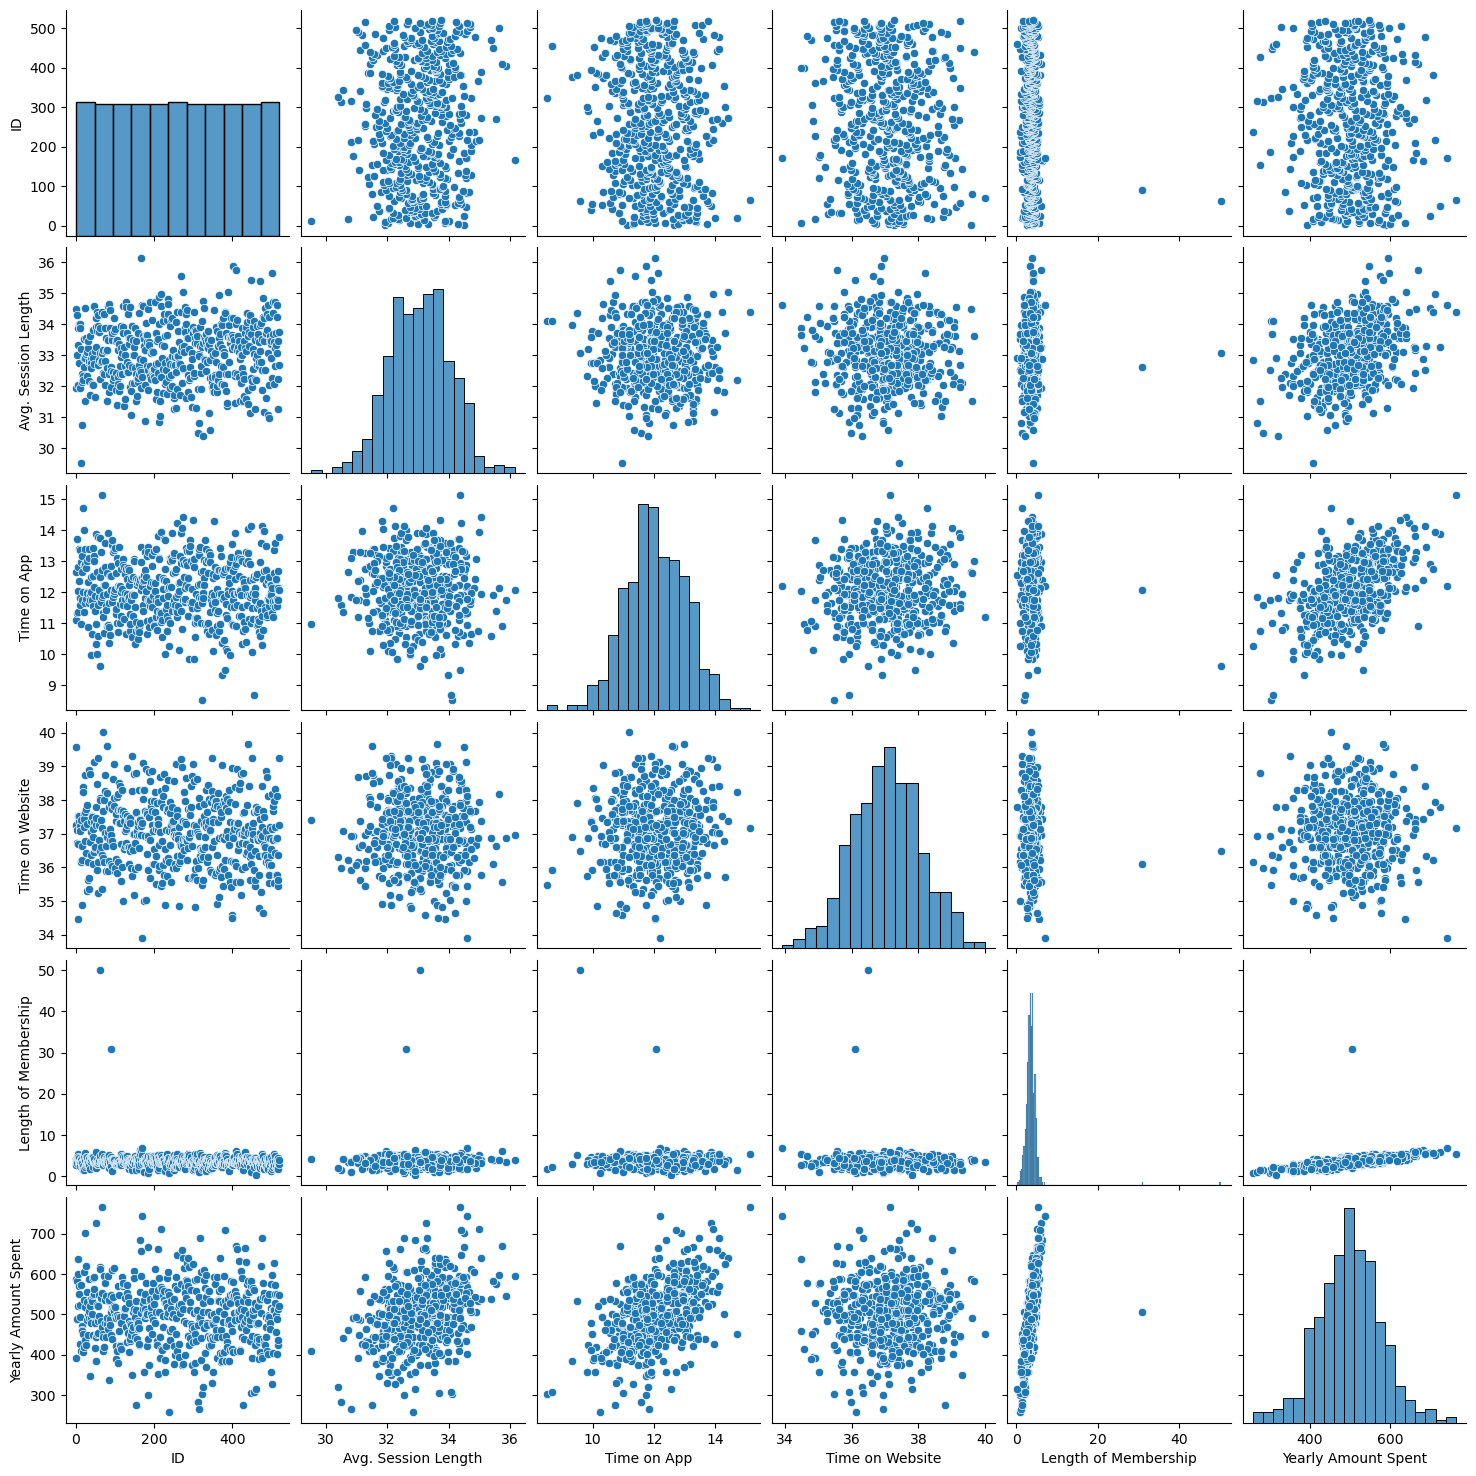

In [14]:
sns.pairplot(data)

In [15]:
data.isnull().sum()

ID                       0
Email                    0
Address                  0
Avatar                   0
Gender                   0
Avg. Session Length      2
Time on App              0
Time on Website          0
Length of Membership     5
Yearly Amount Spent     13
dtype: int64

In [18]:
data['Avg. Session Length'].fillna(data['Avg. Session Length'].mean(), inplace = True) #data = ..... instead of inplace
data.isnull().sum()

ID                       0
Email                    0
Address                  0
Avatar                   0
Gender                   0
Avg. Session Length      0
Time on App              0
Time on Website          0
Length of Membership     5
Yearly Amount Spent     13
dtype: int64

In [26]:
#data.dropna(inplace = True)
data.duplicated().sum()   #Because of ID

20

In [25]:
data = data.drop("ID", axis=1)
data.head()

,Email,Address,Avatar,Gender,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,Female,34.497,12.656,39.578,4.083,587.951
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,Male,31.926,11.109,37.269,2.664,392.205
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,Female,33.001,11.330,37.111,4.105,487.548
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,Male,34.306,13.718,36.721,3.120,581.852
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,Male,33.331,12.795,37.537,4.446,599.406


In [28]:
data = data.drop_duplicates()
data.duplicated().sum()

0

In [29]:
dt = data.copy()  # A copy for testing quantile then apply on original data
dt = dt[(dt['Length of Membership'] <= dt['Length of Membership'].quantile(0.99))]
dt.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,490.000000,490.000000,490.000000,490.000000,478.000000
mean,33.050043,12.059533,37.071351,3.509047,497.455667
std,0.988070,0.996585,1.005128,0.977598,78.658309
min,29.532000,8.508000,34.477000,0.270000,256.671000
25%,32.345000,11.387500,36.353500,2.926250,444.351000
50%,33.087000,11.983000,37.074000,3.522500,497.683000
75%,33.707250,12.777000,37.721000,4.115250,548.885750
max,36.140000,15.127000,40.005000,6.077000,765.518000


In [31]:
data['Gender'] = data['Gender'].replace('Femalee', 'Female')
data['Gender'].value_counts()

Male      275
Female    225
Name: Gender, dtype: int64

In [32]:
data.reset_index()

,index,Email,Address,Avatar,Gender,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,Female,34.497,12.656,39.578,4.083,587.951
1,1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,Male,31.926,11.109,37.269,2.664,392.205
2,2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,Female,33.001,11.330,37.111,4.105,487.548
3,3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,Male,34.306,13.718,36.721,3.120,581.852
4,4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,Male,33.331,12.795,37.537,4.446,599.406
...,...,...,...,...,...,...,...,...,...,...
495,507,lewisjessica@craig-evans.com,"4483 Jones Motorway Suite 872\nLake Jamiefurt,...",Tan,Male,33.238,13.566,36.418,3.747,573.847
496,508,katrina56@gmail.com,"172 Owen Divide Suite 497\nWest Richard, CA 19320",PaleVioletRed,Male,34.703,11.696,37.190,3.577,529.049
497,509,dale88@hotmail.com,"0787 Andrews Ranch Apt. 633\nSouth Chadburgh, ...",Cornsilk,Female,32.647,11.499,38.333,4.958,551.620
498,510,cwilson@hotmail.com,"680 Jennifer Lodge Apt. 808\nBrendachester, TX...",Teal,Female,33.323,12.391,36.840,2.336,456.470


In [38]:
data = data.drop('Email',axis = 1)
data = data.drop('Address',axis = 1)
data = data.drop('Avatar',axis = 1)

In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 500 entries, 0 to 511
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gender                500 non-null    object 
 1   Avg. Session Length   500 non-null    float64
 2   Time on App           500 non-null    float64
 3   Time on Website       500 non-null    float64
 4   Length of Membership  495 non-null    float64
 5   Yearly Amount Spent   487 non-null    float64
dtypes: float64(5), object(1)
memory usage: 27.3+ KB


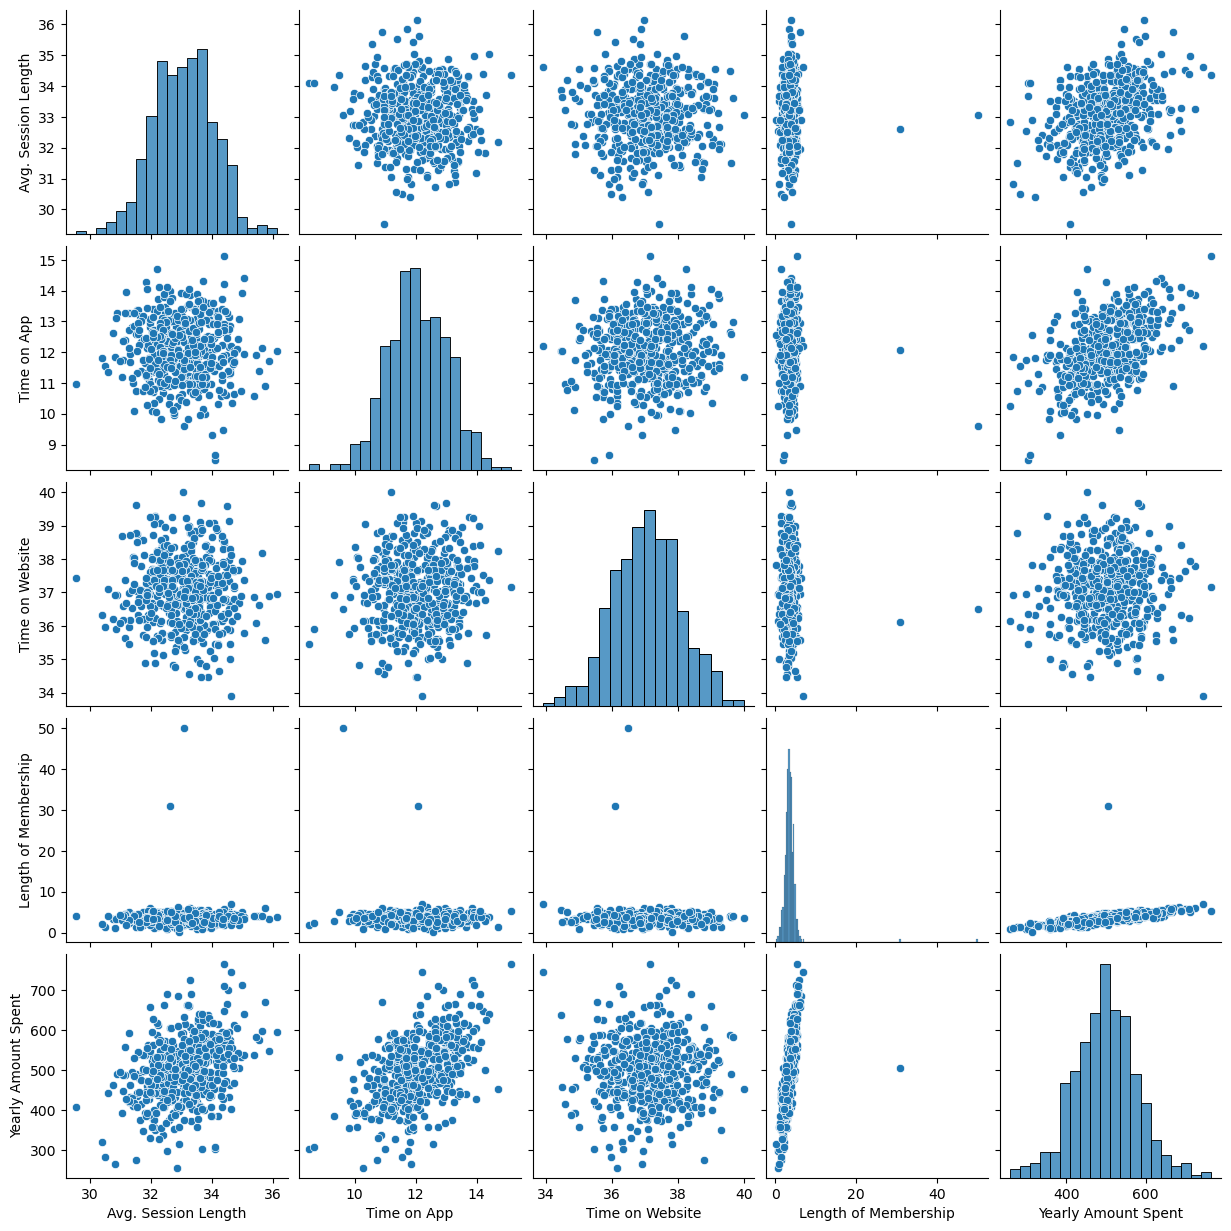

In [41]:
sns.pairplot(data)

In [42]:
#Label encoding, each label refers to a number
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])

In [43]:
data.head()

,Gender,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,0,34.497,12.656,39.578,4.083,587.951
1,1,31.926,11.109,37.269,2.664,392.205
2,0,33.001,11.330,37.111,4.105,487.548
3,1,34.306,13.718,36.721,3.120,581.852
4,1,33.331,12.795,37.537,4.446,599.406


<Axes: >

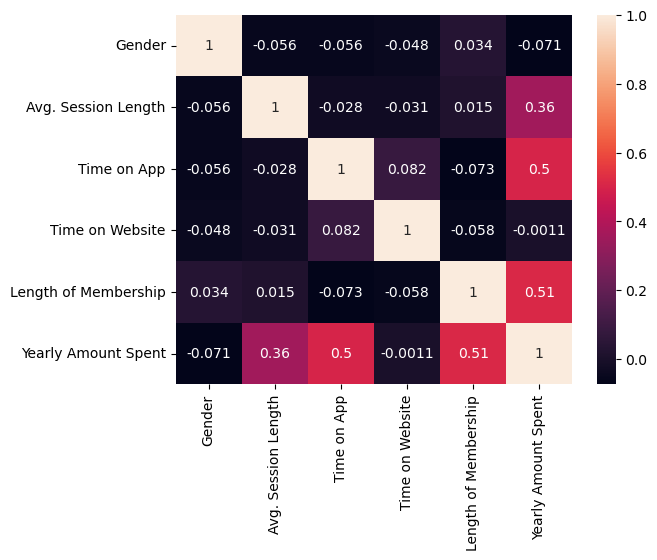

In [44]:
# Feature engineering -> The variables that affect the parameter and there degree of affection (Correlation -> range(-1,1))
# from -30% to 30% -> drop those variables (not effective enough)
sns.heatmap(data.corr(), annot = True)

In [45]:
data.corr()

,Gender,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
Gender,1.000000,-0.055938,-0.056053,-0.047506,0.034496,-0.071242
Avg. Session Length,-0.055938,1.000000,-0.027863,-0.031086,0.015228,0.357223
Time on App,-0.056053,-0.027863,1.000000,0.082391,-0.073361,0.499907
Time on Website,-0.047506,-0.031086,0.082391,1.000000,-0.057567,-0.001143
Length of Membership,0.034496,0.015228,-0.073361,-0.057567,1.000000,0.511315
Yearly Amount Spent,-0.071242,0.357223,0.499907,-0.001143,0.511315,1.000000


In [48]:
correl = data.corr()['Yearly Amount Spent']
col_to_drop = correl[(correl<0.3) & (correl>-0.3)].index
data = data.drop(columns = col_to_drop)

In [50]:
data.info() # data is ready

<class 'pandas.core.frame.DataFrame'>
Int64Index: 500 entries, 0 to 511
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Avg. Session Length   500 non-null    float64
 1   Time on App           500 non-null    float64
 2   Length of Membership  495 non-null    float64
 3   Yearly Amount Spent   487 non-null    float64
dtypes: float64(4)
memory usage: 19.5 KB


In [ ]:
from sklearn.model_selection import train_test_split
x = data.drop('Yearly Amount Spent')
y = data['Yearly Amount Spent']

x_train,x_test,y_train,y_test #Split

In [ ]:
# Standard Scaler
#Linear regression